# Classification fine des polypes — entraînement (Colab)

Ce notebook entraîne un modèle EfficientNet à classifier le **type de polype** selon la nomenclature du manager :

| Classe | Signification |
|---|---|
| `1p` | Polype pédiculé |
| `1s` | Polype sessile |
| `2` | Lésion plane |
| `3` | Lésion ulcérée (dossier `lesion deprime`) |

**Prérequis** : le dossier `deep_polypes2` doit être disponible dans ton Google Drive.
**Runtime** : Exécution > Modifier le type d'exécution > GPU (T4 suffit).

## 1. Installation et imports

In [1]:
!pip install -q torch torchvision scikit-learn matplotlib seaborn albumentations

import os
import shutil
import random
import copy
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", device)

Device utilisé : cuda


## 2. Monter Google Drive et localiser le dossier

In [8]:
from google.colab import drive
drive.mount('/content/drive')

# Adapte ce chemin si besoin — c'est le dossier partagé par les médecins
SOURCE_DIR = "/content/drive/MyDrive/deep_polypes2/deep_polypes/polype"

assert os.path.exists(SOURCE_DIR), f"Dossier introuvable : {SOURCE_DIR} — vérifie le chemin"
print("Contenu de deep_polypes2 :")
for root, dirs, files in os.walk(SOURCE_DIR):
    level = root.replace(SOURCE_DIR, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Contenu de deep_polypes2 :
polype/
  Lesion Plane/
  lesion deprime/
  lesion polypoide/
    Sessile Is/
    Pedicule Ip/


## 3. Réorganiser les données en 4 classes à plat

On ne garde que les sous-dossiers utiles au type de polype (donc uniquement ce qui est sous `polype/`), et on les remappe vers les codes du manager : `1p`, `1s`, `2`, `3`.

In [11]:
import unicodedata

def normalize(s):
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")
    return s.lower().strip()

# Mots-clés à repérer dans le nom du dossier (normalisé) -> classe manager
KEYWORD_MAPPING = [
    (["pedicule"], "1p"),
    (["sessile"], "1s"),
    (["plane"], "2"),
    (["deprime"], "3"),
]

def find_class_folders(source_dir):
    """Parcourt tout l'arbre et associe chaque dossier feuille à une classe si son nom matche."""
    matches = {}
    for root, dirs, files in os.walk(source_dir):
        folder_name = normalize(os.path.basename(root))
        for keywords, class_code in KEYWORD_MAPPING:
            if all(k in folder_name for k in keywords):
                matches[class_code] = root
    return matches

CLASSES = ["1p", "1s", "2", "3"]

found_folders = find_class_folders(SOURCE_DIR)

print("Dossiers détectés automatiquement :")
for c in CLASSES:
    print(f"  {c} -> {found_folders.get(c, '❌ NON TROUVÉ')}")

missing = [c for c in CLASSES if c not in found_folders]
if missing:
    print(f"\n⚠️  Classes non trouvées automatiquement : {missing}")
    print("Dossiers contenant des images détectés dans l'arborescence :")
    for root, dirs, files in os.walk(SOURCE_DIR):
        if any(f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")) for f in files):
            n_imgs = sum(1 for f in files if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")))
            print(f"  {root}  ({n_imgs} images)")

FLAT_DIR = "/content/polype_types_flat"
if os.path.exists(FLAT_DIR):
    shutil.rmtree(FLAT_DIR)
os.makedirs(FLAT_DIR, exist_ok=True)

IMG_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp")
counts = {c: 0 for c in CLASSES}

for class_code, src_folder in found_folders.items():
    dst_folder = os.path.join(FLAT_DIR, class_code)
    os.makedirs(dst_folder, exist_ok=True)
    for fname in os.listdir(src_folder):
        if fname.lower().endswith(IMG_EXTENSIONS):
            src_file = os.path.join(src_folder, fname)
            dst_file = os.path.join(dst_folder, f"{class_code}_{counts[class_code]:04d}{Path(fname).suffix}")
            shutil.copy2(src_file, dst_file)
            counts[class_code] += 1

print("\nNombre d'images par classe :")
for c in CLASSES:
    print(f"  {c} : {counts[c]} images")

total = sum(counts.values())
print(f"\nTotal : {total} images")

Dossiers détectés automatiquement :
  1p -> /content/drive/MyDrive/deep_polypes2/deep_polypes/polype/lesion polypoide/Pedicule Ip
  1s -> /content/drive/MyDrive/deep_polypes2/deep_polypes/polype/lesion polypoide/Sessile Is
  2 -> /content/drive/MyDrive/deep_polypes2/deep_polypes/polype/Lesion Plane
  3 -> /content/drive/MyDrive/deep_polypes2/deep_polypes/polype/lesion deprime

Nombre d'images par classe :
  1p : 40 images
  1s : 1026 images
  2 : 59 images
  3 : 15 images

Total : 1140 images


## 4. Split train / validation

On split **avant** l'augmentation, pour ne jamais avoir de versions augmentées de la même image à la fois en train et en validation (fuite de données).

In [12]:
TRAIN_DIR = "/content/polype_types_split/train"
VAL_DIR = "/content/polype_types_split/val"

for d in [TRAIN_DIR, VAL_DIR]:
    if os.path.exists(d):
        shutil.rmtree(d)
    for c in CLASSES:
        os.makedirs(os.path.join(d, c), exist_ok=True)

VAL_RATIO = 0.2
random.seed(42)

for c in CLASSES:
    class_dir = os.path.join(FLAT_DIR, c)
    files = os.listdir(class_dir)
    if len(files) < 2:
        print(f"⚠️  Classe {c} a trop peu d'images ({len(files)}) pour un split propre.")
        train_files, val_files = files, []
    else:
        train_files, val_files = train_test_split(files, test_size=VAL_RATIO, random_state=42)

    for f in train_files:
        shutil.copy2(os.path.join(class_dir, f), os.path.join(TRAIN_DIR, c, f))
    for f in val_files:
        shutil.copy2(os.path.join(class_dir, f), os.path.join(VAL_DIR, c, f))

    print(f"{c} : {len(train_files)} train / {len(val_files)} val")

1p : 32 train / 8 val
1s : 820 train / 206 val
2 : 47 train / 12 val
3 : 12 train / 3 val


## 5. Augmentation de données

Le dataset étant petit, on applique une augmentation agressive **uniquement sur le train** (jamais sur la validation, pour garder une évaluation honnête).

In [13]:
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=25),
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.2, hue=0.02),
    transforms.RandomAffine(degrees=0, translate=(0.08, 0.08), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

## 6. Dataset PyTorch personnalisé (avec sur-échantillonnage — chaque image vue plusieurs fois avec augmentation différente à chaque epoch)

In [14]:
class PolypTypeDataset(Dataset):
    def __init__(self, root_dir, classes, transform=None, oversample_factor=1):
        self.samples = []
        self.transform = transform
        self.classes = classes
        self.class_to_idx = {c: i for i, c in enumerate(classes)}

        for c in classes:
            class_dir = os.path.join(root_dir, c)
            if not os.path.exists(class_dir):
                continue
            for fname in os.listdir(class_dir):
                self.samples.append((os.path.join(class_dir, fname), self.class_to_idx[c]))

        # Sur-échantillonnage simple : répète la liste (utile si dataset très petit)
        self.samples = self.samples * oversample_factor

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label


train_dataset = PolypTypeDataset(TRAIN_DIR, CLASSES, transform=train_transform, oversample_factor=3)
val_dataset = PolypTypeDataset(VAL_DIR, CLASSES, transform=val_transform, oversample_factor=1)

print(f"Train (avec sur-échantillonnage x3) : {len(train_dataset)} images")
print(f"Validation : {len(val_dataset)} images")

BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

Train (avec sur-échantillonnage x3) : 2733 images
Validation : 229 images


## 7. Pondération des classes (gère le déséquilibre)

Si une classe a beaucoup moins d'images que les autres, on lui donne plus de poids dans la fonction de perte pour éviter que le modèle l'ignore.

In [15]:
class_counts = np.array([counts[c] for c in CLASSES], dtype=np.float32)
class_counts[class_counts == 0] = 1  # évite division par zéro
class_weights = class_counts.sum() / (len(CLASSES) * class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Poids appliqués par classe :")
for c, w in zip(CLASSES, class_weights.cpu().numpy()):
    print(f"  {c} : {w:.2f}")

Poids appliqués par classe :
  1p : 7.12
  1s : 0.28
  2 : 4.83
  3 : 19.00


## 8. Définir le modèle (EfficientNet-B0 pré-entraîné, fine-tuning)

In [16]:
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# On gèle les premières couches (features générales), on entraîne le reste
for param in model.features[:5].parameters():
    param.requires_grad = False

in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, len(CLASSES))
model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 149MB/s]


## 9. Boucle d'entraînement (avec early stopping)

In [18]:
NUM_EPOCHS = 40
PATIENCE = 40

best_val_loss = float("inf")
best_model_weights = copy.deepcopy(model.state_dict())
epochs_no_improve = 0

history = {"train_loss": [], "val_loss": [], "val_acc": []}

for epoch in range(NUM_EPOCHS):
    # --- Entraînement ---
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    train_loss = running_loss / len(train_dataset)

    # --- Validation ---
    model.eval()
    val_loss = 0.0
    correct = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()

    val_loss = val_loss / max(len(val_dataset), 1)
    val_acc = correct / max(len(val_dataset), 1)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} — train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f} | val_acc: {val_acc:.2%}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_weights = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"⏹️  Early stopping à l'epoch {epoch+1} (pas d'amélioration depuis {PATIENCE} epochs)")
            break

model.load_state_dict(best_model_weights)
print("\n✅ Entraînement terminé. Meilleur val_loss :", round(best_val_loss, 4))

Epoch 1/40 — train_loss: 0.1245 | val_loss: 0.5076 | val_acc: 87.77%
Epoch 2/40 — train_loss: 0.1349 | val_loss: 0.5386 | val_acc: 88.21%
Epoch 3/40 — train_loss: 0.1195 | val_loss: 0.5209 | val_acc: 86.90%
Epoch 4/40 — train_loss: 0.0825 | val_loss: 0.5192 | val_acc: 87.34%
Epoch 5/40 — train_loss: 0.1007 | val_loss: 0.5520 | val_acc: 87.34%
Epoch 6/40 — train_loss: 0.0919 | val_loss: 0.5539 | val_acc: 86.46%
Epoch 7/40 — train_loss: 0.0746 | val_loss: 0.5328 | val_acc: 86.90%
Epoch 8/40 — train_loss: 0.0838 | val_loss: 0.5424 | val_acc: 87.77%
Epoch 9/40 — train_loss: 0.0805 | val_loss: 0.5285 | val_acc: 89.52%
Epoch 10/40 — train_loss: 0.0661 | val_loss: 0.5262 | val_acc: 89.08%
Epoch 11/40 — train_loss: 0.0676 | val_loss: 0.5205 | val_acc: 86.90%
Epoch 12/40 — train_loss: 0.0718 | val_loss: 0.5128 | val_acc: 90.39%
Epoch 13/40 — train_loss: 0.0674 | val_loss: 0.5145 | val_acc: 89.52%
Epoch 14/40 — train_loss: 0.0657 | val_loss: 0.5504 | val_acc: 88.65%
Epoch 15/40 — train_loss: 0.0

## 10. Courbes d'entraînement

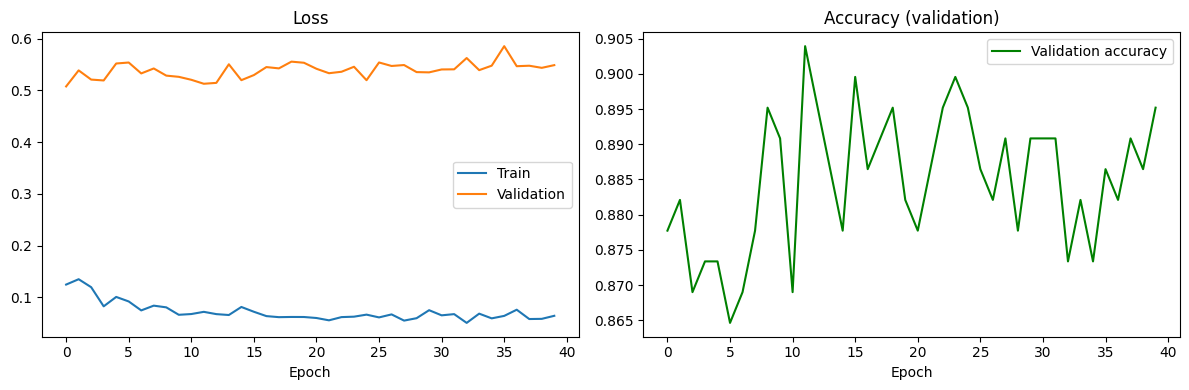

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"], label="Validation")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["val_acc"], label="Validation accuracy", color="green")
axes[1].set_title("Accuracy (validation)")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## 11. Évaluation détaillée (matrice de confusion + rapport)

              precision    recall  f1-score   support

          1p       0.11      0.12      0.12         8
          1s       0.94      0.94      0.94       206
           2       0.40      0.33      0.36        12
           3       0.75      1.00      0.86         3

    accuracy                           0.88       229
   macro avg       0.55      0.60      0.57       229
weighted avg       0.88      0.88      0.88       229



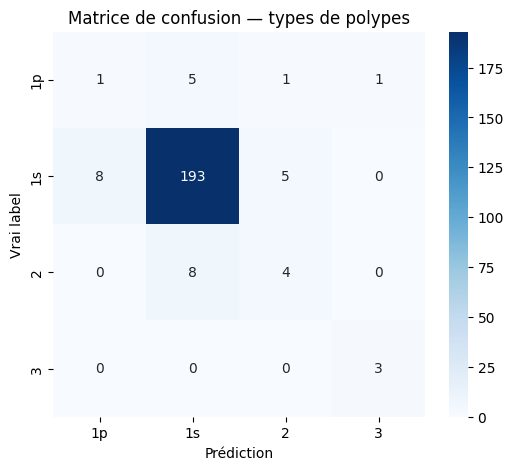

In [20]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=CLASSES, zero_division=0))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel("Prédiction")
plt.ylabel("Vrai label")
plt.title("Matrice de confusion — types de polypes")
plt.show()

## 12. Sauvegarder le modèle sur Drive

Ce fichier est celui à copier dans `weights/` de l'app (`app2.py`), pour la nouvelle fonction de classification fine (étage 2b).

In [21]:
SAVE_PATH = "/content/drive/MyDrive/deep_polypes2/efficientnet_type_polype.pt"
torch.save(model.state_dict(), SAVE_PATH)
print(f"✅ Modèle sauvegardé : {SAVE_PATH}")

# Sauvegarde aussi la correspondance classes <-> index, utile côté app
import json
with open("/content/drive/MyDrive/deep_polypes2/classes_type_polype.json", "w") as f:
    json.dump(CLASSES, f)
print("✅ Fichier de classes sauvegardé : classes_type_polype.json")

✅ Modèle sauvegardé : /content/drive/MyDrive/deep_polypes2/efficientnet_type_polype.pt
✅ Fichier de classes sauvegardé : classes_type_polype.json


## 13. Test rapide d'inférence (vérifier que le modèle chargé fonctionne)

In [22]:
def predict_polyp_type(image_path, model, classes, transform, device):
    image = Image.open(image_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.softmax(output, dim=1)[0]
        idx = int(torch.argmax(probs))
    return classes[idx], float(probs[idx])

# Exemple — remplace par le chemin d'une vraie image de test
example_class = CLASSES[0]
example_dir = os.path.join(VAL_DIR, example_class)
if os.path.exists(example_dir) and os.listdir(example_dir):
    example_image = os.path.join(example_dir, os.listdir(example_dir)[0])
    label, confidence = predict_polyp_type(example_image, model, CLASSES, val_transform, device)
    print(f"Image testée : {example_image}")
    print(f"Prédiction : {label} (confiance : {confidence:.2%})")
else:
    print("Aucune image de validation disponible pour ce test rapide.")

Image testée : /content/polype_types_split/val/1p/1p_0020.jpg
Prédiction : 1s (confiance : 84.03%)


---

## Prochaine étape

Une fois ce modèle entraîné et sauvegardé (`efficientnet_type_polype.pt`), l'intégration dans `app2.py` consistera à :
1. Charger ce modèle en plus du modèle EfficientNet existant (étage 2 actuel).
2. Appliquer la logique de seuils : `< 50%` ignoré, `50-90%` vérification + classification, `> 90%` classification directe.
3. Afficher le type de polype (`1p`, `1s`, `2`, `3`) dans l'interface, en plus du label global existant.

Ce point sera traité séparément, dans `app2.py`, une fois ce modèle validé.